# Notebook 08: Novel Drug-Target Prediction

## AI-Based Identification of Novel Drug Targets for Depression


## Overview

This notebook focuses on identifying potential novel drug-target interactions
using the trained Graph Neural Network model developed in the previous stage.

The GNN model integrates protein structural information represented as
residue-level graphs with drug molecular fingerprint features to learn complex
patterns associated with drug-target interactions.

After training and evaluation, the developed model is applied to candidate
drug-target pairs to estimate interaction probabilities. The predicted
interaction scores are used to rank potential candidates that may represent
promising therapeutic targets related to depression.

This stage extends the previous machine learning and deep learning approaches
by moving from model development towards candidate discovery. The generated
predictions will provide a shortlist of potential drug-target relationships
for further investigation using explainability methods and molecular docking
validation in later stages of the dissertation.


## Dataset

The input data used in this notebook includes:

- Trained Graph Neural Network model generated in Notebook 07.
- Protein graph representations generated from AlphaFold structures.
- Drug molecular fingerprint features.
- Drug-target interaction metadata containing protein and drug identifiers.

The trained model provides the learned representation required to predict
interaction probabilities for candidate drug-target pairs.


## Project Workflow

This notebook represents the eighth stage of the project:

- Load the trained Graph Neural Network model.

- Load protein graph representations and drug molecular features.

- Generate candidate drug-target interaction samples.

- Apply the trained GNN model to predict interaction probabilities.

- Rank candidate drug-target interactions based on prediction scores.

- Analyse the highest-confidence predicted interactions.

- Save prediction results for downstream explainability and molecular docking
  validation.


## Objectives

The objectives of this notebook are:

- Apply the trained GNN model for novel drug-target interaction prediction.

- Generate ranked candidate drug-target interactions associated with
  depression-related proteins.

- Identify high-confidence predictions for further biological analysis.

- Prepare prediction outputs for model explainability and molecular docking
  validation.

- Extend the computational drug discovery pipeline from model development
  towards candidate prioritisation.

In [24]:
# 1. Import Python Libraries


import os
import numpy as np
import pandas as pd


import torch
import torch.nn as nn
import torch.nn.functional as F


import matplotlib.pyplot as plt


from tqdm import tqdm


print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# 2. Environment Configuration


# 2.1 Set Random Seed


SEED = 42


np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)


print(
    "Random seed set to:",
    SEED
)

Random seed set to: 42


In [26]:
# 2.2 Set Up Project Directories


from google.colab import drive


drive.mount(
    "/content/drive"
)


PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)


RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)


PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)


STRUCTURES_PATH = os.path.join(
    RAW_DATA_PATH,
    "structures"
)


MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models"
)


RESULTS_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)


FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)


os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)


os.makedirs(
    FIGURE_PATH,
    exist_ok=True
)


print(
    "Project directories configured successfully."
)


print(
    "\nProject Root:",
    PROJECT_ROOT
)


print(
    "\nRaw Data Path:",
    RAW_DATA_PATH
)


print(
    "\nProcessed Data Path:",
    PROCESSED_DATA_PATH
)


print(
    "\nStructures Path:",
    STRUCTURES_PATH
)


print(
    "\nModel Path:",
    MODEL_PATH
)


print(
    "\nResults Path:",
    RESULTS_PATH
)


print(
    "\nFigure Path:",
    FIGURE_PATH
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories configured successfully.

Project Root: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI

Raw Data Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/raw

Processed Data Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/processed

Structures Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/raw/structures

Model Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models

Results Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results

Figure Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures


In [27]:
# 2.3 Check Hardware Availability


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print(
    "Running device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    print(
        "Running on CPU"
    )

Running device: cuda
GPU: Tesla T4


In [28]:
# 3. Load Trained GNN Model


# 3.1 Check Required Model Directory


print(
    "Checking model directory..."
)


print(
    "Model path:",
    MODEL_PATH
)


print(
    "Model directory exists:",
    os.path.exists(MODEL_PATH)
)

Checking model directory...
Model path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models
Model directory exists: True


In [29]:
# 3.2 Check Available Model Files


if os.path.exists(MODEL_PATH):

    print(
        "Files inside models folder:"
    )


    for file in os.listdir(MODEL_PATH):

        print(
            file
        )

else:

    print(
        "Models folder not found."
    )

Files inside models folder:
random_forest_model.joblib
drug_target_gnn_model.pth


In [30]:
# 3.3 Verify GNN Model File


gnn_model_file = os.path.join(
    MODEL_PATH,
    "drug_target_gnn_model.pth"
)


print(
    "Expected model file:"
)


print(
    gnn_model_file
)


print(
    "Model file exists:",
    os.path.exists(gnn_model_file)
)

Expected model file:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models/drug_target_gnn_model.pth
Model file exists: True


In [31]:
# PyTorch Geometric Dependencies

!pip install torch-geometric

In [32]:
# 3.4 Define GNN Architecture


from torch_geometric.nn import GCNConv, global_mean_pool


class DrugTargetGNN(nn.Module):

    def __init__(
        self,
        protein_features,
        drug_features,
        hidden_dim=128
    ):

        super().__init__()


        # Protein graph encoder

        self.conv1 = GCNConv(
            protein_features,
            hidden_dim
        )


        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )


        # Drug fingerprint encoder

        self.drug_layer = nn.Linear(
            drug_features,
            hidden_dim
        )


        # Interaction classifier

        self.classifier = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                hidden_dim,
                2
            )
        )


    def forward(
        self,
        x,
        edge_index,
        batch,
        drug_features
    ):


        # Protein graph representation

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(
            x
        )


        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(
            x
        )


        protein_embedding = global_mean_pool(
            x,
            batch
        )


        # Drug molecular representation

        drug_embedding = self.drug_layer(
            drug_features
        )

        drug_embedding = F.relu(
            drug_embedding
        )


        # Combine protein and drug representations

        combined_features = torch.cat(
            [
                protein_embedding,
                drug_embedding
            ],
            dim=1
        )


        output = self.classifier(
            combined_features
        )


        return output



print(
    "GNN architecture defined successfully."
)

GNN architecture defined successfully.


In [33]:
# 3.5 Initialise GNN Model


PROTEIN_FEATURE_DIM = 20

DRUG_FEATURE_DIM = 1024


model = DrugTargetGNN(
    protein_features=PROTEIN_FEATURE_DIM,
    drug_features=DRUG_FEATURE_DIM
)


model = model.to(
    device
)


print(
    "GNN model initialised successfully."
)

GNN model initialised successfully.


In [34]:
# 3.6 Load Trained GNN Weights


model.load_state_dict(
    torch.load(
        gnn_model_file,
        map_location=device
    )
)


model.eval()


print(
    "Trained GNN weights loaded successfully."
)

Trained GNN weights loaded successfully.


## 4. Load Required Prediction Data

The trained Graph Neural Network model requires the protein graph representations and molecular features used during the modelling stage.

This section loads the prepared data required for generating predictions with the trained GNN model. The protein graphs were generated from AlphaFold structures in the previous notebook, while the drug molecular features and interaction information are loaded from the processed datasets.

The main inputs used in this stage include:

- Protein residue-level graphs generated from AlphaFold structures.
- Drug molecular fingerprint features.
- Drug-target interaction information required for preparing prediction samples.

These inputs provide the structural and molecular information required by the trained GNN model.

In [35]:
# 4.1 Load Protein Graph Data


import pickle


GRAPH_DATA_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_graphs.pkl"
)


print(
    "Loading protein graph data..."
)


with open(
    GRAPH_DATA_PATH,
    "rb"
) as file:

    protein_graphs = pickle.load(
        file
    )


print(
    "Protein graphs loaded successfully."
)


print(
    "Number of protein graphs:",
    len(protein_graphs)
)

Loading protein graph data...
Protein graphs loaded successfully.
Number of protein graphs: 174


In [36]:
# 4.2 Load Drug-Target Interaction Data


INTERACTION_DATA_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "clean_drug_target_interactions.pkl"
)


print(
    "Loading drug-target interaction data..."
)


interactions_df = pd.read_pickle(
    INTERACTION_DATA_PATH
)


print(
    "Drug-target interaction data loaded successfully."
)


print(
    "Number of interaction records:",
    len(interactions_df)
)


print(
    "Columns:"
)


print(
    interactions_df.columns.tolist()
)

Loading drug-target interaction data...
Drug-target interaction data loaded successfully.
Number of interaction records: 3590
Columns:
['uniprot_id', 'target_chembl_id', 'drug_chembl_id', 'drug_name', 'smiles', 'standard_type', 'standard_value', 'standard_units', 'assay_type', 'pchembl', 'active', 'fingerprint']


In [37]:
# 4.3 Check Drug Fingerprint Features


print(
    "Checking drug fingerprint features..."
)


fingerprint_lengths = (
    interactions_df["fingerprint"]
    .apply(len)
)


print(
    "Fingerprint length:",
    fingerprint_lengths.unique()
)


print(
    "Number of fingerprint features:",
    fingerprint_lengths.iloc[0]
)

Checking drug fingerprint features...
Fingerprint length: [1024]
Number of fingerprint features: 1024


In [38]:
# 4.4 Prepare Prediction Samples


print(
    "Creating protein graph lookup..."
)


protein_graph_lookup = {}


for graph in protein_graphs:

    protein_graph_lookup[
        graph.uniprot_id
    ] = graph


print(
    "Protein graph lookup created."
)


print(
    "Available protein graphs:",
    len(protein_graph_lookup)
)



prediction_samples = []


missing_graphs = 0



for _, row in interactions_df.iterrows():

    uniprot_id = row["uniprot_id"]


    if uniprot_id not in protein_graph_lookup:

        missing_graphs += 1

        continue


    graph = protein_graph_lookup[
        uniprot_id
    ]


    sample = graph.clone()


    # Drug fingerprint features
    # Add batch dimension for GNN processing

    sample.drug_features = torch.tensor(
        row["fingerprint"],
        dtype=torch.float32
    ).unsqueeze(0)


    sample.uniprot_id = (
        uniprot_id
    )


    sample.drug_chembl_id = (
        row["drug_chembl_id"]
    )


    sample.active = int(
        row["active"]
    )


    prediction_samples.append(
        sample
    )



print(
    "\nPrediction samples prepared successfully."
)


print(
    "Total prediction samples:",
    len(prediction_samples)
)


print(
    "Missing protein graphs:",
    missing_graphs
)

Creating protein graph lookup...
Protein graph lookup created.
Available protein graphs: 174

Prediction samples prepared successfully.
Total prediction samples: 3590
Missing protein graphs: 0


## 5. Generate GNN Predictions

The trained Graph Neural Network model is used to predict drug-target interactions using the prepared protein graph representations and drug molecular features.

The model is set to evaluation mode to prevent parameter updates during prediction. Each protein-drug sample is passed through the trained GNN architecture to obtain prediction probabilities and predicted interaction classes.

The generated predictions will be used for further analysis and evaluation of the model's ability to identify potential drug-target interactions.

In [39]:
# 5.1 Generate Predictions Using Trained GNN Model


from torch_geometric.loader import DataLoader


print(
    "Generating GNN predictions..."
)


model.eval()


prediction_loader = DataLoader(
    prediction_samples,
    batch_size=32,
    shuffle=False
)


all_predictions = []
all_probabilities = []
all_labels = []
all_uniprot_ids = []
all_drug_ids = []


with torch.no_grad():

    for batch in prediction_loader:

        batch = batch.to(device)


        output = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.drug_features
        )


        probabilities = torch.softmax(
            output,
            dim=1
        )


        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        all_predictions.extend(
            predictions.cpu().numpy()
        )


        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )


        all_labels.extend(
            batch.active.cpu().numpy()
        )


        all_uniprot_ids.extend(
            batch.uniprot_id
        )


        all_drug_ids.extend(
            batch.drug_chembl_id
        )


print(
    "Prediction generation completed."
)


print(
    "Total predictions:",
    len(all_predictions)
)

Generating GNN predictions...
Prediction generation completed.
Total predictions: 3590


## 6. Analyse Prediction Results

The generated GNN predictions are analysed to understand the model output and compare predicted interaction classes with the original activity labels.

This section combines the predicted probabilities, predicted classes, and interaction metadata into a single results dataframe. The prediction confidence scores provide additional information about the model's certainty when identifying potential drug-target interactions.

In [40]:
# 6.1 Create Prediction Results DataFrame


prediction_results = pd.DataFrame(
    {
        "uniprot_id": all_uniprot_ids,
        "drug_chembl_id": all_drug_ids,
        "true_label": all_labels,
        "predicted_label": all_predictions,
        "prediction_probability": all_probabilities
    }
)


print(
    "Prediction results dataframe created successfully."
)


print(
    "Number of prediction records:",
    len(prediction_results)
)


prediction_results.head()

Prediction results dataframe created successfully.
Number of prediction records: 3590


,uniprot_id,drug_chembl_id,true_label,predicted_label,prediction_probability
0,P31645,CHEMBL322923,0,0,0.000359
1,P31645,CHEMBL435341,1,1,0.999383
2,P31645,CHEMBL311347,1,1,0.998662
3,P31645,CHEMBL100941,1,1,0.999997
4,P31645,CHEMBL174088,1,1,1.000000


In [41]:
# 6.1.1 Rank Candidate Drug-Target Interactions


ranked_predictions = prediction_results.sort_values(
    by="prediction_probability",
    ascending=False
)


print(
    "Candidate interactions ranked successfully."
)


print(
    "Top 10 predicted drug-target interactions:"
)


ranked_predictions.head(10)

Candidate interactions ranked successfully.
Top 10 predicted drug-target interactions:


,uniprot_id,drug_chembl_id,true_label,predicted_label,prediction_probability
7,P31645,CHEMBL106939,1,1,1.0
4,P31645,CHEMBL174088,1,1,1.0
15,P31645,CHEMBL432394,1,1,1.0
3537,P43681,CHEMBL2179551,1,1,1.0
3538,P43681,CHEMBL2179547,1,1,1.0
3539,P43681,CHEMBL2179559,1,1,1.0
1555,P49286,CHEMBL333810,1,1,1.0
1558,P49286,CHEMBL124216,1,1,1.0
1559,P49286,CHEMBL123634,1,1,1.0
1544,P49286,CHEMBL435586,1,1,1.0


In [42]:
# 6.2 Evaluate Prediction Performance


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


accuracy = accuracy_score(
    prediction_results["true_label"],
    prediction_results["predicted_label"]
)


precision = precision_score(
    prediction_results["true_label"],
    prediction_results["predicted_label"]
)


recall = recall_score(
    prediction_results["true_label"],
    prediction_results["predicted_label"]
)


f1 = f1_score(
    prediction_results["true_label"],
    prediction_results["predicted_label"]
)


print(
    "GNN Prediction Performance"
)


print(
    "Accuracy:",
    round(accuracy, 4)
)


print(
    "Precision:",
    round(precision, 4)
)


print(
    "Recall:",
    round(recall, 4)
)


print(
    "F1-score:",
    round(f1, 4)
)

GNN Prediction Performance
Accuracy: 0.9565
Precision: 0.9582
Recall: 0.9705
F1-score: 0.9643


In [43]:
# 6.3 Generate Confusion Matrix


from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    prediction_results["true_label"],
    prediction_results["predicted_label"]
)


print(
    "Confusion Matrix:"
)


print(cm)

Confusion Matrix:
[[1326   92]
 [  64 2108]]


In [44]:
# 7. Save Prediction Results


prediction_output_path = os.path.join(
    RESULTS_PATH,
    "gnn_prediction_results.csv"
)


prediction_results.to_csv(
    prediction_output_path,
    index=False
)


print(
    "Prediction results saved successfully."
)


print(
    "Saved file:",
    prediction_output_path
)

Prediction results saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_prediction_results.csv


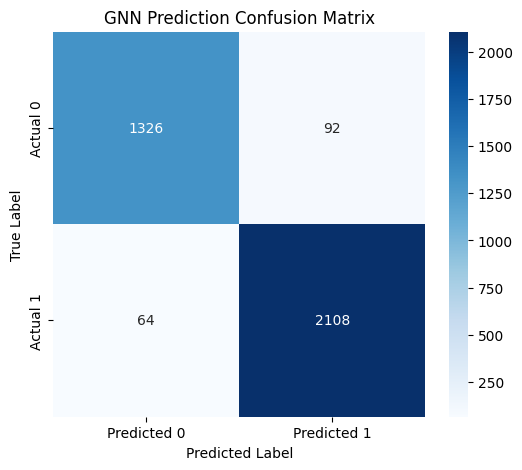

Prediction confusion matrix figure saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures/gnn_prediction_confusion_matrix.png


In [45]:
# 8. Visualise Prediction Confusion Matrix


import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted 0",
        "Predicted 1"
    ],
    yticklabels=[
        "Actual 0",
        "Actual 1"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "GNN Prediction Confusion Matrix"
)


prediction_confusion_matrix_path = os.path.join(
    FIGURE_PATH,
    "gnn_prediction_confusion_matrix.png"
)


plt.savefig(
    prediction_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Prediction confusion matrix figure saved successfully."
)


print(
    "Saved file:",
    prediction_confusion_matrix_path
)

In [46]:
# 9. Save GNN Prediction Evaluation Summary


evaluation_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1
        ]
    }
)


evaluation_summary_path = os.path.join(
    RESULTS_PATH,
    "gnn_prediction_evaluation_summary.csv"
)


evaluation_summary.to_csv(
    evaluation_summary_path,
    index=False
)


print(
    "Evaluation summary saved successfully."
)


print(
    "Saved file:",
    evaluation_summary_path
)


evaluation_summary

Evaluation summary saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_prediction_evaluation_summary.csv


,Metric,Value
0,Accuracy,0.956546
1,Precision,0.958182
2,Recall,0.970534
3,F1-score,0.964318


In [47]:
# 10. Save ranked candidate predictions


ranked_predictions_path = os.path.join(
    RESULTS_PATH,
    "gnn_ranked_candidate_predictions.csv"
)


ranked_predictions.to_csv(
    ranked_predictions_path,
    index=False
)


print(
    "Ranked candidate predictions saved successfully."
)


print(
    "Saved file:",
    ranked_predictions_path
)

Ranked candidate predictions saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_ranked_candidate_predictions.csv


## Summary

This notebook applied the trained Graph Neural Network model for drug-target interaction prediction using protein structural information and molecular fingerprint features.

The prepared protein residue-level graphs generated from AlphaFold structures were combined with drug molecular fingerprints to create prediction samples. The trained GNN model was then used to generate interaction predictions and confidence scores for the drug-target pairs.

The model predictions were analysed using classification metrics, including accuracy, precision, recall, and F1-score. A confusion matrix was also generated to visualise the prediction performance across active and inactive interaction classes.

The prediction results and evaluation outputs were saved for further analysis and comparison with other machine learning approaches developed in this dissertation.

This notebook completes the graph-based deep learning stage of the project by applying the trained GNN model to predict potential drug-target interactions.